In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\irene\Desktop\DataAnalytics\Bootcamp\Simulacro empresarial\ProjecteData\Equip_19\Data\tourist_accommodation_10112025_clean.csv")

# Habitaciones con outliers

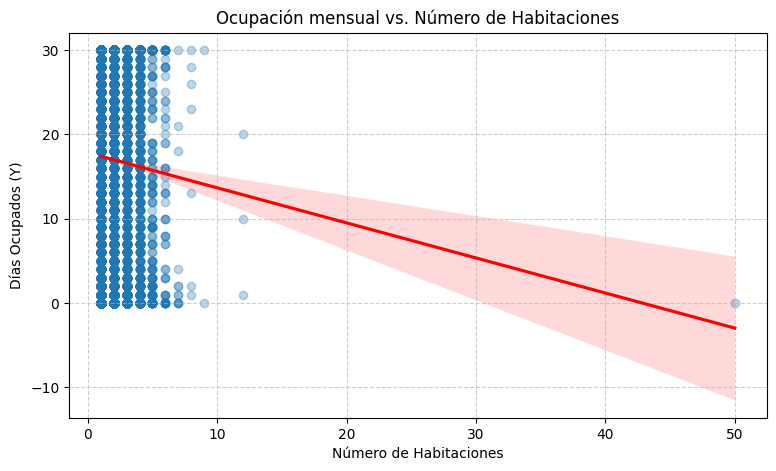

In [2]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='bedrooms', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Habitaciones')
plt.xlabel('Número de Habitaciones')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
df['bedrooms'].value_counts()

bedrooms
1.0     4587
2.0     2315
3.0     1522
4.0      700
5.0      190
6.0       67
7.0       12
8.0        7
12.0       3
9.0        2
50.0       1
Name: count, dtype: int64

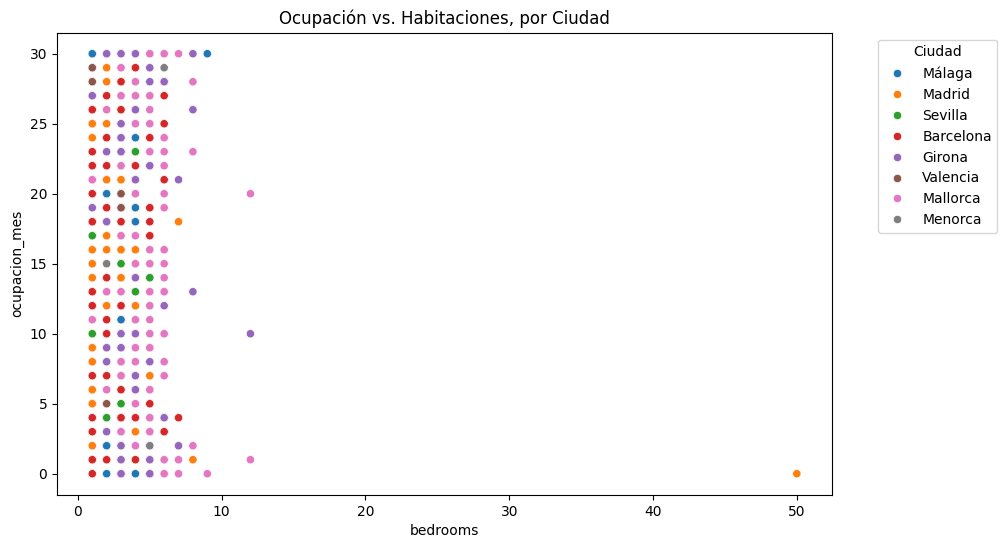

In [4]:
# Gráfico de dispersión con color por Ciudad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='bedrooms',
    y='ocupacion_mes',
    hue='city',  # Agrega color basado en la ciudad
    data=df
)
plt.title('Ocupación vs. Habitaciones, por Ciudad')
plt.legend(title='Ciudad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Camas con outliers

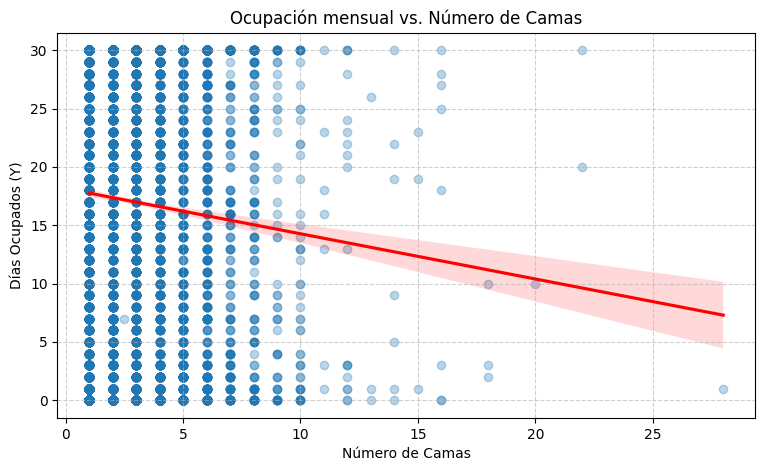

In [5]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='beds', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Camas')
plt.xlabel('Número de Camas')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
df[['beds']].value_counts()

beds
1.0     3167
2.0     1832
3.0     1530
4.0     1124
5.0      753
6.0      479
7.0      209
8.0      150
9.0       58
10.0      50
12.0      18
16.0       8
11.0       7
14.0       7
18.0       3
13.0       3
15.0       3
22.0       2
2.5        1
20.0       1
28.0       1
Name: count, dtype: int64

# Baños con outliers

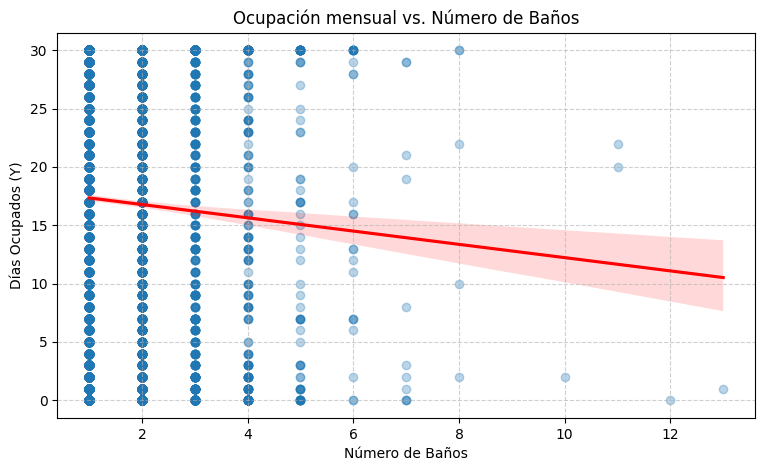

In [7]:
plt.figure(figsize=(9, 5))
# Usamos lmplot para incluir automáticamente la línea de regresión (linealidad)
sns.regplot(
    x='bathrooms', 
    y='ocupacion_mes',
    data=df, 
    scatter_kws={'alpha': 0.3}, # Hacemos los puntos más transparentes
    line_kws={'color': 'red'}  # Línea de regresión roja
)
plt.title('Ocupación mensual vs. Número de Baños')
plt.xlabel('Número de Baños')
plt.ylabel('Días Ocupados (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
df[['bathrooms']].value_counts()

bathrooms
1            5788
2            2641
3             620
4             231
5              77
6              28
7              11
8               5
11              2
10              1
12              1
13              1
Name: count, dtype: int64

# Graficos para comparaciones con outliers

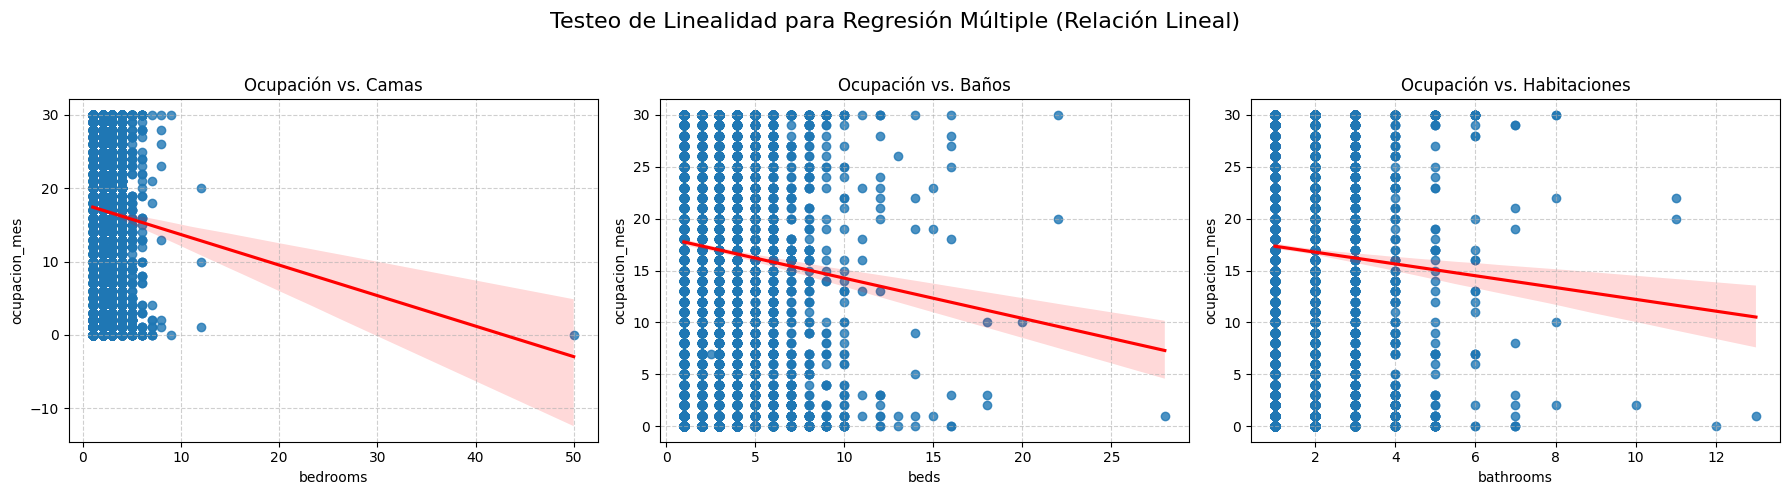

In [9]:
# --- 1. Definición de la Rejilla ---
# fig: El lienzo completo.
# axes: Un array (matriz) con los 3 espacios para los gráficos.
# (1, 3): Significa 1 Fila, 3 Columnas.
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
# figsize=(18, 5) da un buen ancho para que los 3 gráficos quepan bien.

# --- 2. Dibujar cada gráfico en su posición ---
# Accedemos a cada posición de la lista 'axes' (la indexación empieza en 0):

# Gráfico 1:  Ocupación vs. Habitaciones (eje en la posición [0])
sns.regplot(x='bedrooms', y='ocupacion_mes', data=df, ax=axes[0], line_kws={'color': 'red'})
axes[2].set_title('Ocupación vs. Habitaciones')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Ocupación vs. Camas (eje en la posición [1])
sns.regplot(x='beds', y='ocupacion_mes', data=df, ax=axes[1], line_kws={'color': 'red'})
axes[0].set_title('Ocupación vs. Camas')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Ocupación vs. Baños (eje en la posición [2])
sns.regplot(x='bathrooms', y='ocupacion_mes', data=df, ax=axes[2], line_kws={'color': 'red'})
axes[1].set_title('Ocupación vs. Baños')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- 3. Ajustes finales ---
fig.suptitle('Testeo de Linealidad para Regresión Múltiple (Relación Lineal)', fontsize=16) 
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajusta el espacio entre gráficos para que no se superpongan los títulos
# 
plt.show()

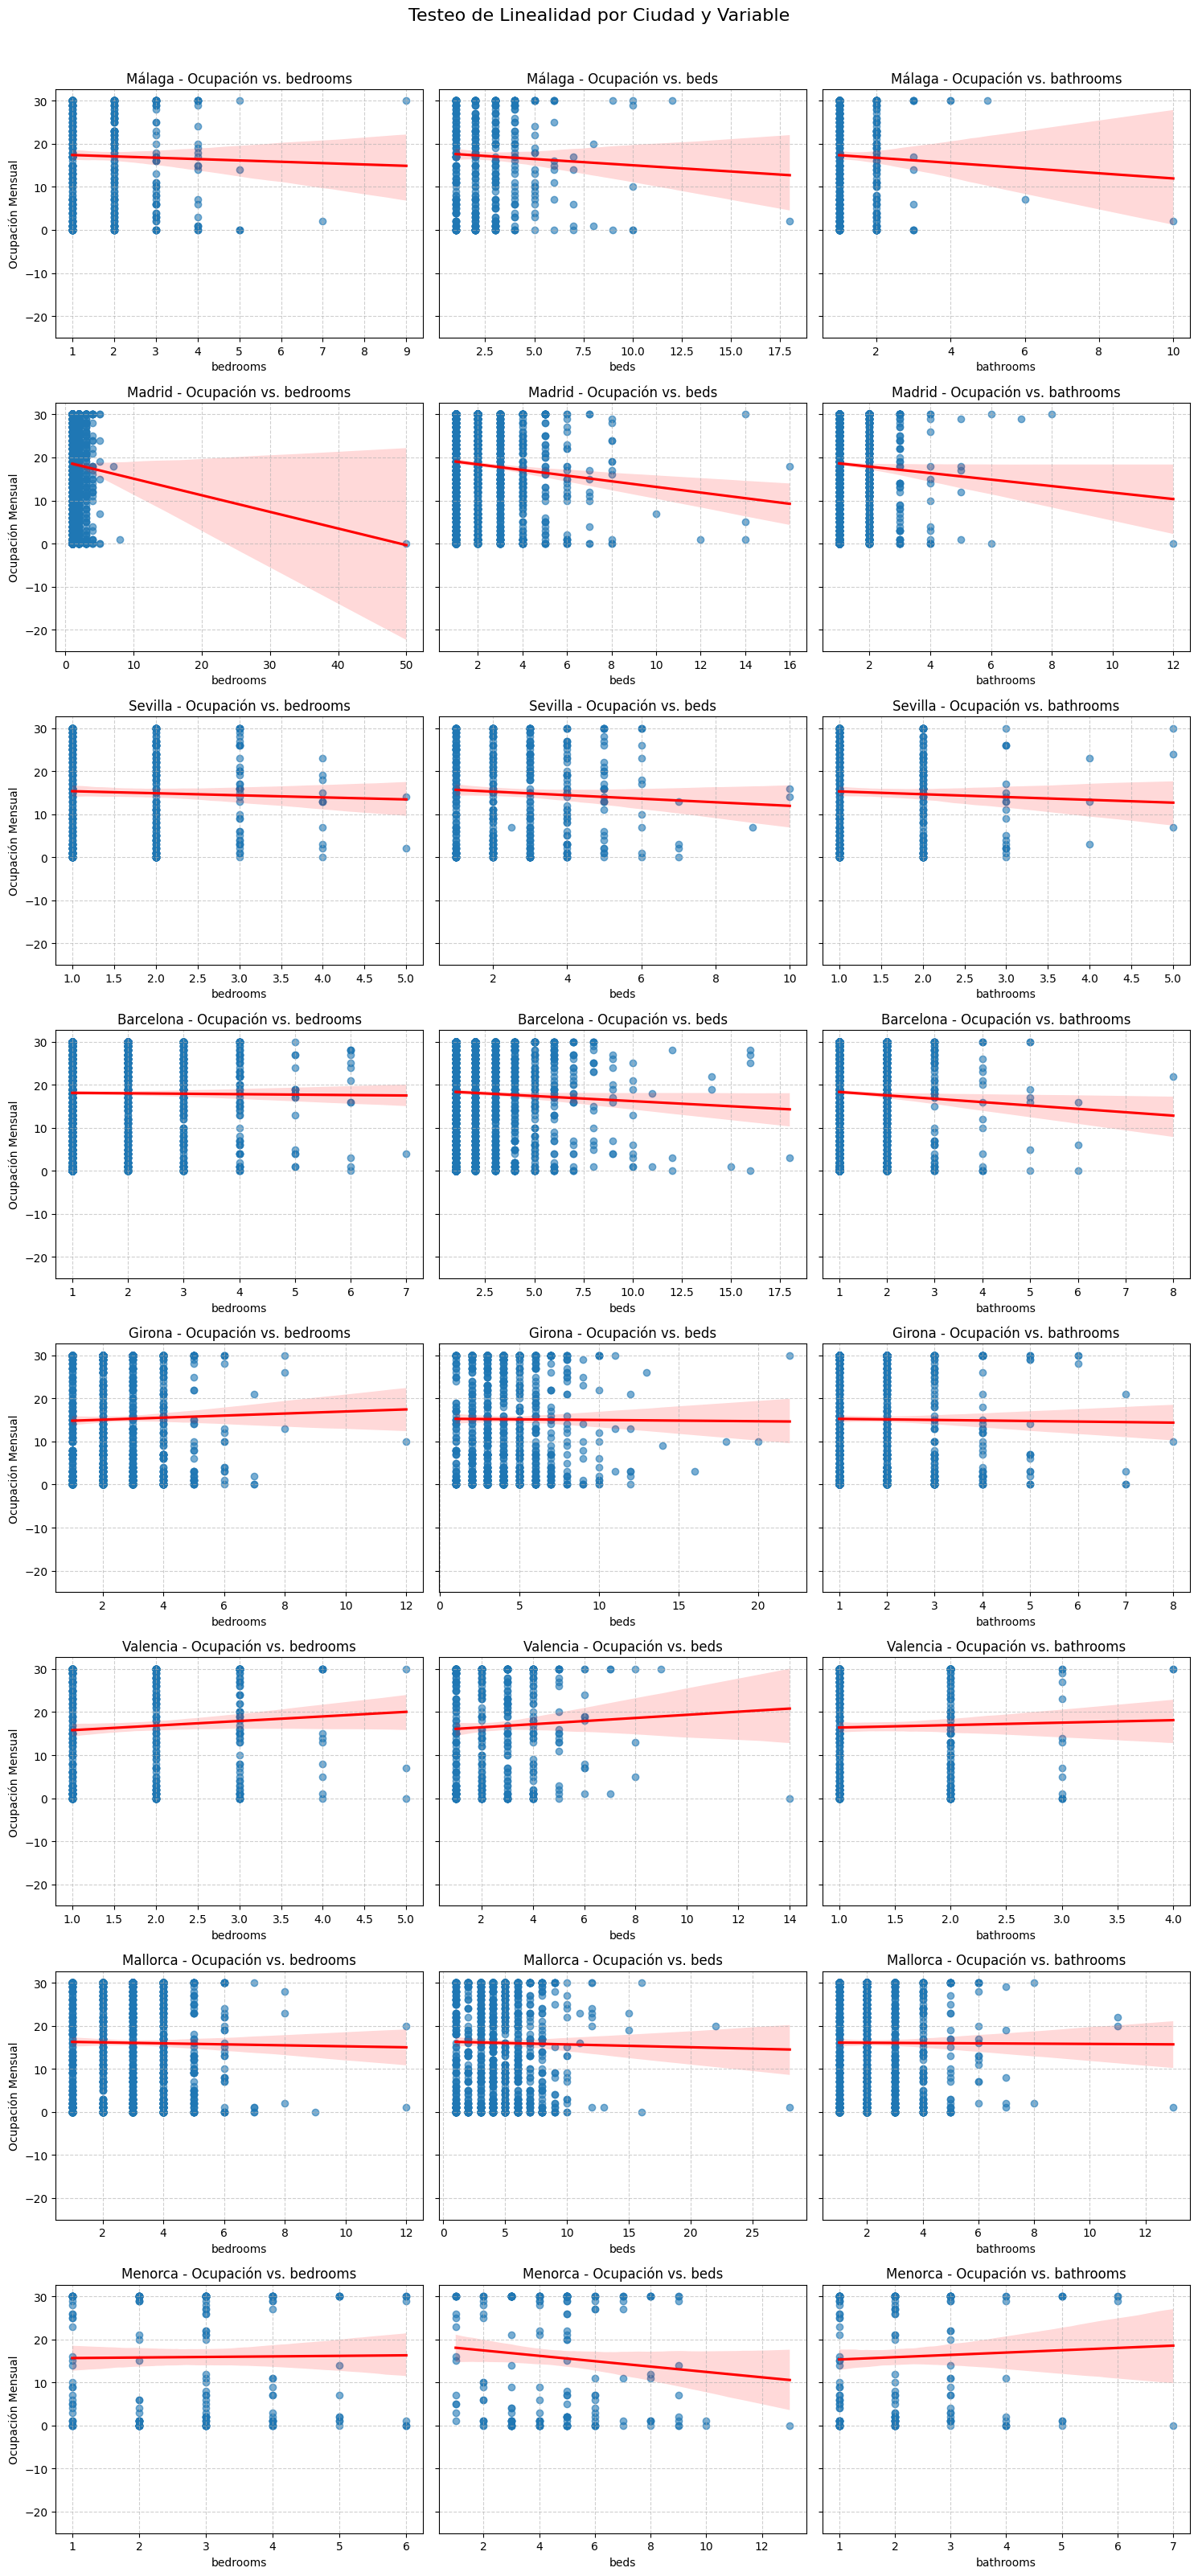

In [10]:
# Variables independientes a testear
variables_x = ['bedrooms', 'beds', 'bathrooms']
ciudades = df['city'].unique()

# Definimos la rejilla: 
# Filas = Número de Ciudades
# Columnas = Número de variables_x
fig, axes = plt.subplots(len(ciudades), len(variables_x), 
                         figsize=(5 * len(variables_x), 4 * len(ciudades)), 
                         sharey=True) # Compartimos el eje Y para facilitar la comparación

# Iteramos sobre las ciudades (Filas)
for i, ciudad in enumerate(ciudades):
    df_ciudad = df[df['city'] == ciudad]
    
    # Iteramos sobre las variables X (Columnas)
    for j, x_var in enumerate(variables_x):
        # Seleccionamos el subplot actual
        ax = axes[i, j] 
        
        # Usamos regplot, pasándole el eje específico 'ax'
        sns.regplot(
            x=x_var, 
            y='ocupacion_mes',
            data=df_ciudad, 
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'}
        )
        
        # Título para cada gráfico
        ax.set_title(f'{ciudad} - Ocupación vs. {x_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel('Ocupación Mensual' if j == 0 else '') # Solo la primera columna tiene el label Y
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle('Testeo de Linealidad por Ciudad y Variable', fontsize=16, y=1.0)
# 
plt.show()

# Capping variables para eliminar outliers

In [13]:
df_sin_outliers = df.copy()
# 1. Definir las variables a procesar
variables_a_limitar = ['bathrooms', 'bedrooms', 'beds']

print("--- 📏 Aplicando Capping SOLO al Límite Superior por IQR (1.5) ---")

for columna in variables_a_limitar:
    print(f"\nProcesando columna: '{columna}'")
    
    # 2. Calcular Q1, Q3, e IQR
    Q1 = df_sin_outliers[columna].quantile(0.25)
    Q3 = df_sin_outliers[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # 3. Definir SOLO el Límite Superior
    limite_superior = Q3 + 1.5 * IQR
    
    # --- 4. Aplicar el Capping Superior ---
    
    # Identificar registros que superan el límite superior
    registros_sup = df_sin_outliers[columna] > limite_superior
    total_limitados = registros_sup.sum()
    
    # Acotar valores superiores
    df_sin_outliers[columna] = np.where(
        df_sin_outliers[columna] > limite_superior,
        limite_superior, # Si es mayor, sustituirlo por el límite superior
        df_sin_outliers[columna]
    )
    
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite Superior (Capping): {limite_superior:.2f}")
    print(f"  **Total de {columna} limitados: {total_limitados} (solo superiores)**")

print("\n--- ✅ Proceso de Capping completado, evitando la limitación inferior innecesaria. ---")

--- 📏 Aplicando Capping SOLO al Límite Superior por IQR (1.5) ---

Procesando columna: 'bathrooms'
  Q1: 1.00, Q3: 2.00, IQR: 1.00
  Límite Superior (Capping): 3.50
  **Total de bathrooms limitados: 357 (solo superiores)**

Procesando columna: 'bedrooms'
  Q1: 1.00, Q3: 3.00, IQR: 2.00
  Límite Superior (Capping): 6.00
  **Total de bedrooms limitados: 25 (solo superiores)**

Procesando columna: 'beds'
  Q1: 1.00, Q3: 4.00, IQR: 3.00
  Límite Superior (Capping): 8.50
  **Total de beds limitados: 161 (solo superiores)**

--- ✅ Proceso de Capping completado, evitando la limitación inferior innecesaria. ---


# Visualizaciones comparativas sin outliers

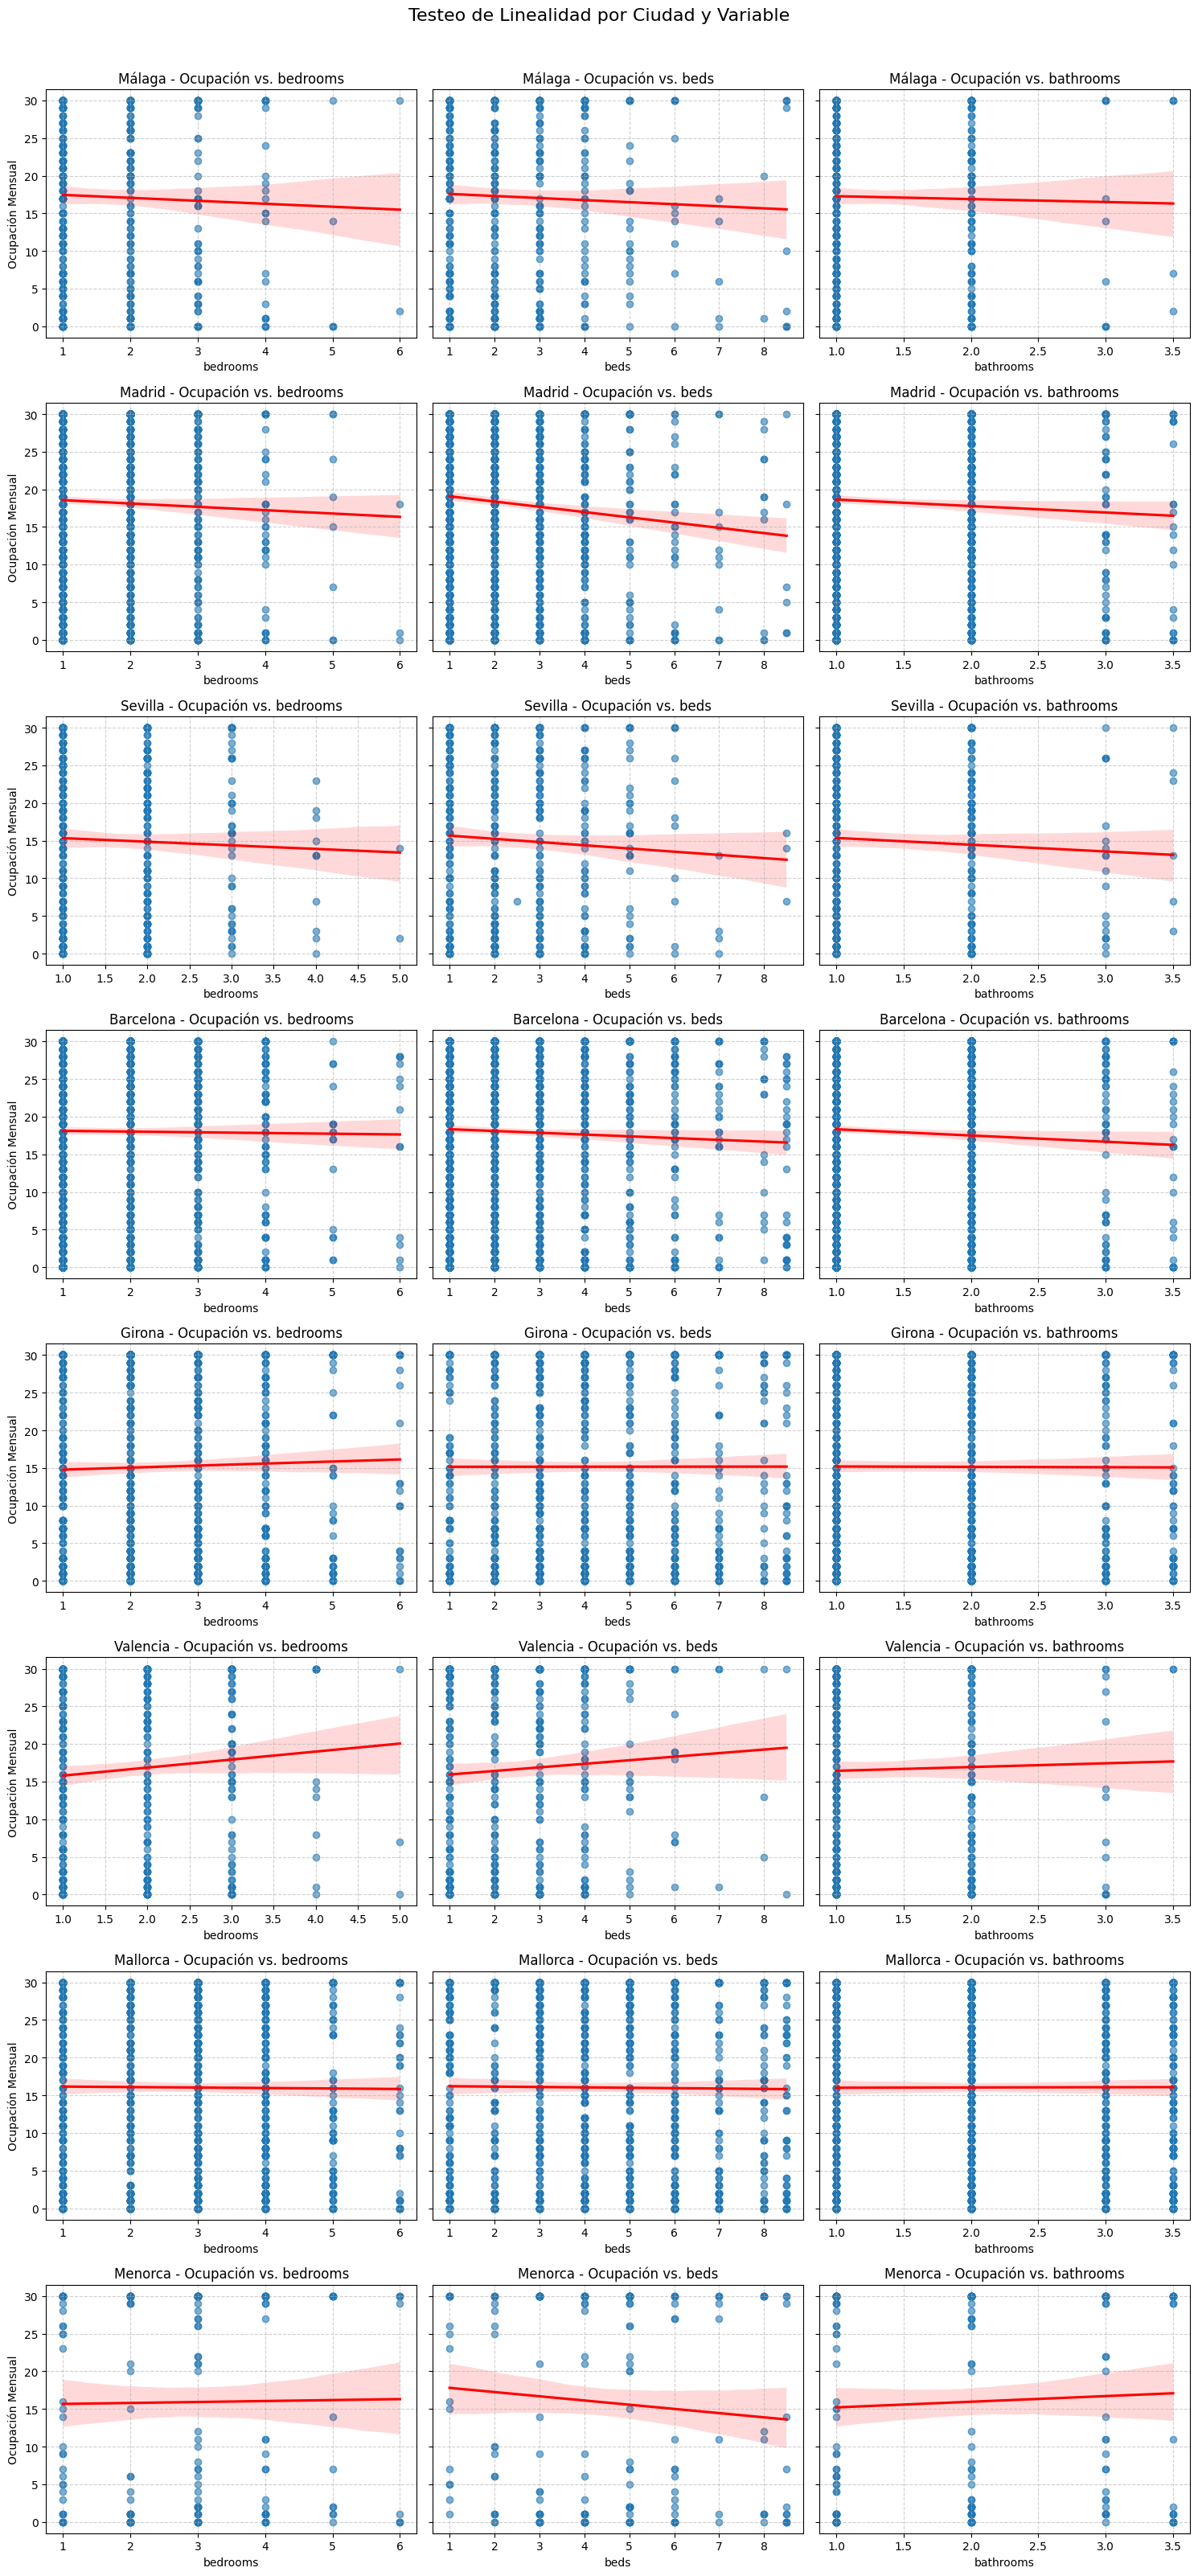

In [14]:
# Variables independientes a testear
variables_x = ['bedrooms', 'beds', 'bathrooms']
ciudades = df_sin_outliers['city'].unique()

# Definimos la rejilla: 
# Filas = Número de Ciudades
# Columnas = Número de variables_x
fig, axes = plt.subplots(len(ciudades), len(variables_x), 
                         figsize=(5 * len(variables_x), 4 * len(ciudades)), 
                         sharey=True) # Compartimos el eje Y para facilitar la comparación

# Iteramos sobre las ciudades (Filas)
for i, ciudad in enumerate(ciudades):
    df_ciudad = df_sin_outliers[df_sin_outliers['city'] == ciudad]
    
    # Iteramos sobre las variables X (Columnas)
    for j, x_var in enumerate(variables_x):
        # Seleccionamos el subplot actual
        ax = axes[i, j] 
        
        # Usamos regplot, pasándole el eje específico 'ax'
        sns.regplot(
            x=x_var, 
            y='ocupacion_mes',
            data=df_ciudad, 
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'}
        )
        
        # Título para cada gráfico
        ax.set_title(f'{ciudad} - Ocupación vs. {x_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel('Ocupación Mensual' if j == 0 else '') # Solo la primera columna tiene el label Y
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle('Testeo de Linealidad por Ciudad y Variable', fontsize=16, y=1.0)
# 
plt.show()